In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.patches import Patch

import os
import sys
import numpy as np 
from pathlib import Path
# Get the root folder (two levels up from this file)
root_folder = Path.cwd().parent

# Add to sys.path
sys.path.append(str(root_folder))

from importlib.machinery import SourceFileLoader
import matplotlib.pyplot as plt
import json 
from pathlib import Path
from matplotlib.patches import Rectangle, Circle
from matplotlib.lines import Line2D
from collections import defaultdict
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

from optimization import ff_scenario as ff  # wherever ff lives
from optimization.ff_scenario import obs, robot_radius, table  # must exist in your repo
from dynamics.freeflyer import FreeflyerModel, ocp_no_obstacle_avoidance, ocp_obstacle_avoidance, ocp_obstacle_avoidance_feasibility, compute_constraint_to_go, sample_init_target

In [14]:

def to_mask(idx, N):
    """Safe boolean mask from index list/array/None."""
    m = np.zeros(N, dtype=bool)
    if idx is None:
        return m
    arr = np.asarray(idx).ravel()
    if arr.size:
        arr = arr.astype(int)
        arr = arr[(arr >= 0) & (arr < N)]
        m[arr] = True
    return m


def make_bins(ctgs0, ctg_min=1, ctg_max=45, step=5):
    """
    Build final bin ids with a virtual '0' bin for ctg==0.

    Returns
    -------
    bin_ids_final : (N,) int in [0..n_bins-1]
    labels_full   : list[str] of length n_bins
    edges_core    : 1D array of float, len = n_bins (without the PS bin)
    """
    n = int((ctg_max - ctg_min + 1) / step)  # e.g. (45-1+1)/5 = 9
    edges_core = np.linspace(ctg_min, ctg_max, num=n + 1)
    bin_ids_core = np.clip(
        np.digitize(ctgs0, edges_core, right=False) - 1,
        0,
        len(edges_core) - 2,
    )

    bin_ids_final = bin_ids_core + 1   # shift for PS bin at 0
    ps_mask = np.isclose(ctgs0, 0.0)
    bin_ids_final[ps_mask] = 0

    labels_core = [
        f"{int(edges_core[i])}-{int(edges_core[i + 1])}"
        for i in range(len(edges_core) - 1)
    ]
    labels_full = ["0"] + labels_core
    return bin_ids_final, labels_full, edges_core


def counts_by_bin(mask, bin_ids, n_bins):
    """Count True entries of mask per bin id."""
    if not np.any(mask):
        return np.zeros(n_bins, dtype=int)
    return np.bincount(bin_ids[mask], minlength=n_bins).astype(int)


def half_violin(ax, data_list, positions, width, side, color, alpha, mean="center"):
    """Draw (half-)violins with mean ticks on given axis."""
    if not data_list:
        return

    v = ax.violinplot(
        data_list,
        positions=positions,
        widths=width,
        showmeans=False,
        showextrema=False,
    )

    for body, p in zip(v["bodies"], positions):
        verts = body.get_paths()[0].vertices
        if side == "left":
            verts[verts[:, 0] > p, 0] = p
        elif side == "right":
            verts[verts[:, 0] < p, 0] = p
        body.set_facecolor(color)
        body.set_alpha(alpha)
        body.set_edgecolor("none")

    # mean ticks
    for d, p in zip(data_list, positions):
        if len(d) == 0:
            continue
        m = float(np.mean(d))
        if mean == "left":
            ax.plot([p - 0.15, p - 0.02], [m, m], lw=2, color=color)
        elif mean == "right":
            ax.plot([p + 0.02, p + 0.15], [m, m], lw=2, color=color)
        else:
            ax.plot([p - 0.12, p + 0.12], [m, m], lw=2, color=color)


def prune_empty(datasets, positions):
    """Drop empty datasets while keeping positions aligned."""
    data_ok, pos_ok = [], []
    for d, p in zip(datasets, positions):
        arr = np.asarray(d).ravel()
        if arr.size:
            data_ok.append(arr.astype(float))
            pos_ok.append(p)
    return data_ok, pos_ok


def per_bin_arrays(values, ctgs0, edges_core, keep_idx_set):
    """Split `values` into lists of arrays per [edges_core] bin."""
    values = np.asarray(values)
    out = []
    for i in range(len(edges_core) - 1):
        lo, hi = edges_core[i], edges_core[i + 1]
        idx = np.where((ctgs0 >= lo) & (ctgs0 < hi))[0]
        if keep_idx_set is not None:
            idx = [j for j in idx if j in keep_idx_set]
        out.append(values[idx].astype(float).ravel())
    return out


def plot_metric_half_violins(
    ax,
    bin_ids,
    n_bins,
    m_domain,
    mask,
    vals_left,
    vals_right,
    color_left,
    color_right,
    alpha_left,
    alpha_right,
):
    """Helper for panels (3) and (4): two-sided half violins per non-PS bin."""
    data_left, data_right, pos_left, pos_right = [], [], [], []
    for b in range(1, n_bins):  # skip PS bin 0
        in_bin = (bin_ids == b) & m_domain
        v_left = vals_left[in_bin & mask]
        v_right = vals_right[in_bin & mask]
        if v_left.size:
            data_left.append(v_left)
            pos_left.append(b)
        if v_right.size:
            data_right.append(v_right)
            pos_right.append(b)

    if data_left:
        half_violin(
            ax,
            data_left,
            pos_left,
            width=0.8,
            side="left",
            color=color_left,
            alpha=alpha_left,
            mean="left",
        )
    if data_right:
        half_violin(
            ax,
            data_right,
            pos_right,
            width=0.8,
            side="right",
            color=color_right,
            alpha=alpha_right,
            mean="right",
        )
    # match original: lighten all collections afterwards
    plt.setp(ax.collections, alpha=0.3)


def plot_cvx_art_summary(
    J_cvx,
    J_art,
    J_cvx_scp,
    J_art_scp,
    ctgs0,
    i_infeas_cvx,
    i_infeas_cvx_scp,
    i_infeas_art_scp,
    iter_cvx,
    iter_art,
    runtime_cvx_scp,
    runtime_DT_scp,
    runtime_DT,          # pure SAGES inference time
    ctg_min=1,
    ctg_max=25,
    step=5,
):
    """
    Reproduce the original 2x2 figure (stacked counts, cost offsets,
    iteration counts, total runtime) as a function of CVX cumulative
    constraint violation, now also overlaying SAGES inference time
    (green) on the runtime panel.
    """
    N = len(J_cvx)

    # ---- masks (one pass) ----
    m_cvx_infeas     = to_mask(i_infeas_cvx, N)
    m_cvx_scp_infeas = to_mask(i_infeas_cvx_scp, N)
    m_art_scp_infeas = to_mask(i_infeas_art_scp, N)

    m_domain = ~m_cvx_infeas
    m_ps     = np.isclose(ctgs0, 0.0)
    m_nonps  = m_domain & (~m_ps)

    # ---- bins (final ids with PS=0) ----
    bin_ids, labels_full, edges_core = make_bins(
        ctgs0,
        ctg_min=ctg_min,
        ctg_max=ctg_max,
        step=step,
    )
    n_bins = len(labels_full)
    x      = np.arange(n_bins)

    # ---- colors ----
    C = {
        "cvx":     "tab:red",
        "cvx-scp": "tab:blue",
        "art":     "tab:green",
        "art-scp": "tab:orange",
    }

    # ---- stacked counts (bars) ----
    # PS bin: count only domain&PS, shown twice at bin 0
    ps_counts = counts_by_bin(m_domain & m_ps, bin_ids, n_bins)

    # non-PS per-pipeline outcome
    cvx_conv = m_nonps & (~m_cvx_scp_infeas)
    art_conv = m_nonps & (~m_art_scp_infeas)
    cvx_inf  = m_nonps & m_cvx_scp_infeas
    art_inf  = m_nonps & m_art_scp_infeas

    cvx_conv_cnt = counts_by_bin(cvx_conv, bin_ids, n_bins)
    art_conv_cnt = counts_by_bin(art_conv, bin_ids, n_bins)
    cvx_inf_cnt  = counts_by_bin(cvx_inf,  bin_ids, n_bins)
    art_inf_cnt  = counts_by_bin(art_inf,  bin_ids, n_bins)

    # bar layout
    w, dx = 0.40, 0.20
    x_cvx, x_art = x - dx, x + dx

    # ---- figure layout ----
    fig = plt.figure(figsize=(11, 5))
    gs  = gridspec.GridSpec(2, 2, figure=fig, width_ratios=[1, 1])
    ax_stack   = fig.add_subplot(gs[0, 0])
    ax_cost    = fig.add_subplot(gs[0, 1])
    ax_iter    = fig.add_subplot(gs[1, 0])
    ax_runtime = fig.add_subplot(gs[1, 1])
    rot = 45  # rotation angle of x tick labels

    # (1) stacked counts
    if n_bins > 0:
        ax_stack.bar(
            x_cvx[0], ps_counts[0],
            width=w, color=C["art"], alpha=0.95, label="CVX-PS",
        )
        ax_stack.bar(
            x_art[0], ps_counts[0],
            width=w, color=C["art"], alpha=0.95,
        )

    # bins 1..: bottom (converged, blue) + top (infeasible, red/orange)
    sl = slice(1, None)
    ax_stack.bar(
        x_cvx[sl], cvx_conv_cnt[sl],
        width=w, color=C["cvx-scp"], alpha=0.80,
        label="CVX-SCP converged",
    )
    ax_stack.bar(
        x_cvx[sl], cvx_inf_cnt[sl],
        width=w, bottom=cvx_conv_cnt[sl],
        color="tab:red", alpha=0.95,
        label="CVX-SCP infeas.",
    )
    ax_stack.bar(
        x_art[sl], art_conv_cnt[sl],
        width=w, color=C["cvx-scp"], alpha=0.50,
        label="SAGES converged",
    )
    ax_stack.bar(
        x_art[sl], art_inf_cnt[sl],
        width=w, bottom=art_conv_cnt[sl],
        color=C["art-scp"], alpha=0.95,
        label="SAGES infeas.",
    )

    # Δ labels above the pair (only if both converged bars exist)
    nonps_total = cvx_conv_cnt + cvx_inf_cnt
    y_max = max(nonps_total.max(), ps_counts[0] if ps_counts.size else 0)
    y_off = 0.01 * (y_max if y_max > 0 else 1.0)
    for b in range(1, n_bins):
        if art_conv_cnt[b] and cvx_conv_cnt[b]:
            ax_stack.text(
                x[b],
                nonps_total[b] + y_off,
                f"Δ={int(art_conv_cnt[b] - cvx_conv_cnt[b]):+d}",
                ha="center", va="bottom", fontsize=8,
            )

    ax_stack.set_xticks(x)
    ax_stack.set_xticklabels(labels_full, rotation=rot)
    ax_stack.set_xlabel(r"Cumulative constraint violation (CVX), $c_1$")
    ax_stack.set_ylabel("Count")
    ax_stack.legend(loc="upper right", ncols=1, fontsize=7.5)
    ymin, ymax = ax_stack.get_ylim()
    ax_stack.set_ylim(0, ymax + 0.12 * (ymax - ymin))

    # (2) costs per CTG bin (half-violins)
    # "feasible in both SCP variants"
    feas_idx = set(range(N)) \
        - set(np.where(m_cvx_scp_infeas)[0]) \
        - set(np.where(m_art_scp_infeas)[0])

    cost_art    = per_bin_arrays(J_art     - J_cvx, ctgs0, edges_core, feas_idx)
    cost_cvxscp = per_bin_arrays(J_cvx_scp - J_cvx, ctgs0, edges_core, feas_idx)
    cost_artscp = per_bin_arrays(J_art_scp - J_cvx, ctgs0, edges_core, feas_idx)

    bins   = np.arange(len(edges_core) - 1)  # no PS bin here
    W, sep = 0.4, 0.2
    pos_sym  = bins - sep    # SAGES symmetric
    pos_asym = bins + sep    # CVX-SCP (left) / SAGES-SCP (right)

    art_ok,    pos_sym_ok   = prune_empty(cost_art,    pos_sym)
    cvx_ok,    pos_left_ok  = prune_empty(cost_cvxscp, pos_asym)
    artscp_ok, pos_right_ok = prune_empty(cost_artscp, pos_asym)

    # draw violins
    if art_ok:
        half_violin(
            ax_cost, art_ok, pos_sym_ok, W,
            side="full", color=C["art"], alpha=0.85, mean="center",
        )
    if cvx_ok:
        half_violin(
            ax_cost, cvx_ok, pos_left_ok, W,
            side="left", color=C["cvx-scp"], alpha=0.80, mean="left",
        )
    if artscp_ok:
        half_violin(
            ax_cost, artscp_ok, pos_right_ok, W,
            side="right", color=C["art-scp"], alpha=0.90, mean="right",
        )

    # cosmetics
    ax_cost.hlines(
        0.0,
        xmin=bins.min() - 0.6 if len(bins) else -0.6,
        xmax=bins.max() + 0.6 if len(bins) else 0.6,
        color="red", linestyle="--", linewidth=1,
    )
    plt.setp(ax_cost.collections, alpha=0.3)
    ax_cost.set_xticks(bins)
    ax_cost.set_xticklabels(
        [f"{int(edges_core[i])}-{int(edges_core[i + 1])}"
         for i in range(len(edges_core) - 1)],
        rotation=rot,
    )
    ax_cost.set_ylabel("Cost offset from CVX\n  (waypoint-hopping), m/s")
    ax_cost.set_xlabel(r"Cumulative constraint violation (CVX), $c_1$")
    ax_cost.legend(
        handles=[
            Patch(facecolor=C["art"],     alpha=0.85, label="SAGES-WS"),
            Patch(facecolor=C["cvx-scp"], alpha=0.80, label="CVX-SCP"),
            Patch(facecolor=C["art-scp"], alpha=0.90, label="SAGES"),
        ],
        loc="upper left", fontsize=8,
    )
    # ax_cost.set_ylim(-50, 170)

    # (3) iteration counts per bin (half-violins, skip PS bin)
    good_cvx = np.isfinite(iter_cvx) & (iter_cvx > 0)
    converged_mask_iter = (~m_cvx_scp_infeas) & (~m_art_scp_infeas) & good_cvx

    plot_metric_half_violins(
        ax_iter,
        bin_ids,
        n_bins,
        m_domain,
        converged_mask_iter,
        vals_left=iter_cvx,
        vals_right=iter_art,
        color_left=C["cvx-scp"],
        color_right=C["art-scp"],
        alpha_left=0.80,
        alpha_right=0.90,
    )

    ax_iter.set_xticks(np.arange(n_bins))
    ax_iter.set_xticklabels(labels_full, rotation=rot)
    ax_iter.set_xlabel(r"Cumulative constraint violation (CVX), $c_1$")
    ax_iter.set_ylabel("Iteration Count")
    ax_iter.legend(
        handles=[
            Patch(facecolor=C["cvx-scp"], alpha=0.80, label="CVX-SCP"),
            Patch(facecolor=C["art-scp"], alpha=0.90, label="SAGES"),
        ],
        loc="upper left", fontsize=8,
    )
    ymin, ymax = ax_iter.get_ylim()
    ax_iter.set_ylim(bottom=0)

    # (4) runtime per bin (half-violins, skip PS bin)
    #   left  = CVX-SCP total runtime (CPU)
    #   right = SAGES-SCP total runtime (CPU+GPU) in orange
    #           + SAGES inference-only time (GPU) in green, overlaid
    converged_mask_runtime = (~m_cvx_scp_infeas) & (~m_art_scp_infeas)

    data_cvx, data_art_scp, data_art_inf = [], [], []
    pos_cvx, pos_art_scp, pos_art_inf = [], [], []

    for b in range(1, n_bins):  # skip PS bin 0
        in_bin = (bin_ids == b) & m_domain & converged_mask_runtime

        vals_c      = runtime_cvx_scp[in_bin]
        vals_artscp = runtime_DT_scp[in_bin]
        vals_artDT  = runtime_DT[in_bin]

        if vals_c.size:
            data_cvx.append(vals_c)
            pos_cvx.append(b)
        if vals_artscp.size:
            data_art_scp.append(vals_artscp)
            pos_art_scp.append(b)
        if vals_artDT.size:
            data_art_inf.append(vals_artDT)
            pos_art_inf.append(b)

    # left: CVX-SCP runtime
    if data_cvx:
        half_violin(
            ax_runtime,
            data_cvx,
            pos_cvx,
            0.8,
            side="left",
            color=C["cvx-scp"],
            alpha=0.80,
            mean="left",
        )

    # right (outer): SAGES-SCP total runtime
    if data_art_scp:
        half_violin(
            ax_runtime,
            data_art_scp,
            pos_art_scp,
            0.8,
            side="right",
            color=C["art-scp"],
            alpha=0.90,
            mean="right",
        )

    # right (inner overlay): pure SAGES inference time (GPU), green
    if data_art_inf:
        half_violin(
            ax_runtime,
            data_art_inf,
            pos_art_inf,
            0.4,   # narrower for visual separation
            side="right",
            color=C["art"],
            alpha=0.80,
            mean="right",
        )

    plt.setp(ax_runtime.collections, alpha=0.3)
    ax_runtime.set_xticks(np.arange(n_bins))
    ax_runtime.set_xticklabels(labels_full, rotation=rot)
    ax_runtime.set_xlabel(r"Cumulative constraint violation (CVX), $c_1$")
    ax_runtime.set_ylabel("Total runtime, s")
    ax_runtime.legend(
        handles=[
            Patch(facecolor=C["cvx-scp"], alpha=0.80, label="CVX-SCP (CPU)"),
            Patch(facecolor=C["art-scp"], alpha=0.90, label="SAGES (CPU+GPU)"),
            Patch(facecolor=C["art"],     alpha=0.80, label="SAGES-WS (GPU)"),
        ],
        loc="upper right",
        fontsize=8,
    )
    ymin, ymax = ax_runtime.get_ylim()
    ax_runtime.set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()
    # fig.savefig("ff_post_scp_analysis_orin.png", dpi=600)
    fig.savefig("ff_post_scp_analysis_orin.png", dpi=600, bbox_inches='tight', pad_inches=0.1)

    return fig, (ax_stack, ax_cost, ax_iter, ax_runtime)

In [10]:
# HELPER FUNCTIONS
def _scp_action_costs(actions: np.ndarray,
                      infeas_idx: np.ndarray | None = None) -> np.ndarray:
    """
    Given actions (N, n_action, T), compute per-sample SCP cost:
        J_i = sum_t ||a_i[:,t]||_1

    If infeas_idx is provided, those entries are set to NaN and can be
    dropped later.
    """
    if actions is None:
        return None
    A = np.asarray(actions, dtype=float)
    if A.ndim != 3:
        raise ValueError(f"actions must be (N, n_action, T), got {A.shape}")
    norms = np.linalg.norm(A, ord=1, axis=1)  # (N, T)
    cost = np.sum(norms, axis=1)*1e0 # 1e0 m/sec , 1e3mm/sec            # (N,)
    if infeas_idx is not None and len(infeas_idx) > 0:
        infeas_idx = np.asarray(infeas_idx, dtype=int)
        cost[infeas_idx] = np.nan
    return cost

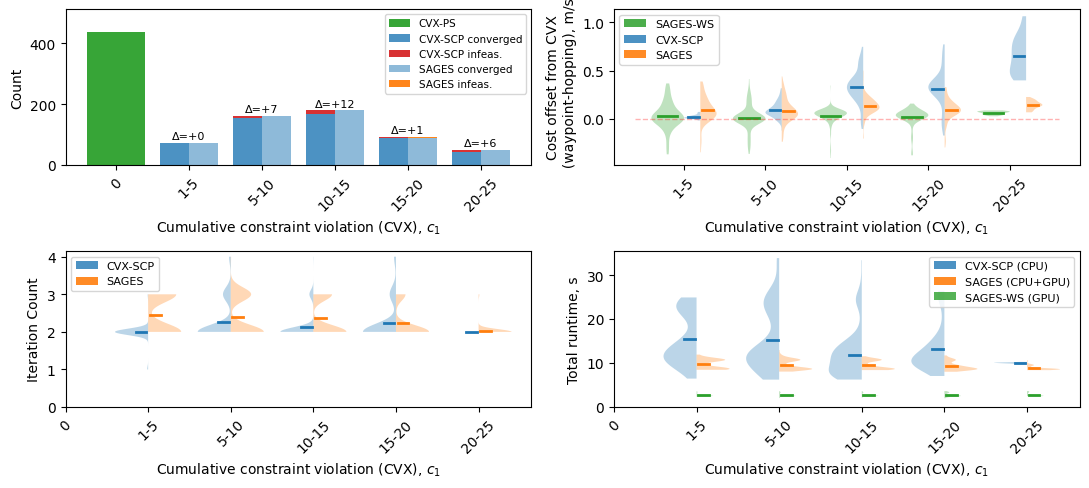

In [15]:
### Load warm start data
model_version_name = 'v_06'
ws_version = 'v_06_orin_80k_unseen' #'v_01_total' , 'v_06_orin_80k_unseen', 'v_06_80k_unseen' # warmstarting analysis version
npz_path=Path(root_folder) / "optimization" / "saved_files" / "warmstarting" / f"ws_analysis_{ws_version}.npz"
data = np.load(npz_path, allow_pickle=True)

J_cvx = _scp_action_costs(data["actions_cvx"],
                          infeas_idx=data["i_unfeas_cvx"])

# --- DT-CTG (normal or OP) warmstart fuel cost -------------------
use_ctg_op= False
if not use_ctg_op:
    J_dt = _scp_action_costs(data["actions_ws_DT_ctg"],
                             infeas_idx=data["i_unfeas_DT_ctg"])
    dt_name = "DT-CTG"
else:
    J_dt = _scp_action_costs(data["actions_ws_DT_ctg_op"],
                             infeas_idx=data["i_unfeas_DT_ctg_op"])
    dt_name = "DT-CTG-OP"
J_art = J_dt
J_cvx_scp = _scp_action_costs(data["actions_scp_cvx"],
                              infeas_idx=data["i_unfeas_scp_cvx"])
# --- DT-SCP final fuel cost --------------------------------------
if not use_ctg_op:
    J_dt_scp = _scp_action_costs(data["actions_scp_DT_ctg"],
                                 infeas_idx=data["i_unfeas_DT_ctg"])
    dt_scp_name = "DT-CTG-SCP"
else:
    J_dt_scp = _scp_action_costs(data["actions_scp_DT_ctg_op"],
                                 infeas_idx=data["i_unfeas_DT_ctg_op"])
    dt_scp_name = "DT-CTG-OP-SCP"

J_art_scp = J_dt_scp

ctgs0_cvx = np.asarray(data['ctgs0_cvx'], dtype=float)
i_infeas_cvx     = data['i_unfeas_cvx']
i_infeas_cvx_scp = data['i_unfeas_scp_cvx']
iter_cvx = np.asarray(data['iter_scp_cvx'], dtype=float)

runtime_cvx     = np.asarray(data['runtime_cvx'])
runtime_cvx_scp = np.asarray(data['runtime_scp_cvx']) + runtime_cvx

if not use_ctg_op:
    iter_art = np.asarray(data['iter_scp_DT_ctg'], dtype=float)
    runtime_DT  = np.asarray(data['runtime_DT_ctg'])
    runtime_DT_scp = np.asarray(data['runtime_scp_DT_ctg']) + runtime_DT
    i_infeas_art_scp = data['i_unfeas_DT_ctg']
        
else:
    iter_art = np.asarray(data['iter_scp_DT_ctg_op'], dtype=float)
    runtime_DT  = np.asarray(data['runtime_DT_ctg_op'])
    runtime_DT_scp = np.asarray(data['runtime_scp_DT_ctg_op']) + runtime_DT
    i_infeas_art_scp = data['i_unfeas_DT_ctg_op']
    

############################################################
# Call Plotting
fig, (ax_stack, ax_cost, ax_iter, ax_runtime) = plot_cvx_art_summary(
    J_cvx,
    J_art,
    J_cvx_scp,
    J_art_scp,
    ctgs0_cvx,
    i_infeas_cvx,
    i_infeas_cvx_scp,
    i_infeas_art_scp,
    iter_cvx,
    iter_art,
    runtime_cvx_scp,
    runtime_DT_scp,
    runtime_DT,
)

